# K-Nearest Neighbours (KNN)

In [10]:
import sys; sys.path.insert(0, "..")

from utils.dependencies import *
from utils import (
    load_and_filter, impute, split_and_balance, FEATURES,
    get_class_meta,
    run_grid_search,
    print_classification_report, compute_f1_scores, run_stratified_cv, print_error_patterns,
    plot_f1_bar, plot_confusion_matrices, plot_posterior_violins,
)

## Model-Specific Data Processing

In [11]:
df = load_and_filter()
df = impute(df)

LOG_COLS = ["pl_bmasse", "pl_orbper", "pl_orbsmax", "sy_dist"]
for col in LOG_COLS:
    df[col] = np.log1p(df[col].clip(lower=0))

for col in FEATURES:
    lo, hi = df[col].quantile([0.01, 0.99])
    df[col] = df[col].clip(lower=lo, upper=hi)

X_train_bal, y_train_bal, X_test_scaled, y_test, class_weight_dict, scaler = split_and_balance(
    df,
    scaler=RobustScaler(),
    smote_variant="borderline",
)

pca = PCA(n_components=0.95, random_state=42)
X_train_bal = pca.fit_transform(X_train_bal)
X_test_scaled = pca.transform(X_test_scaled)

class_names, classes, colors = get_class_meta()
print(f"PCA: {len(FEATURES)} features → {X_train_bal.shape[1]} components (95% variance retained)")

Loaded: (5569, 18)
Nulls before imputation:
pl_orbper       260
pl_orbsmax     2237
pl_orbeccen    3315
pl_bmasse      2986
pl_rade        1373
pl_eqt         2402
st_teff         290
st_rad          321
st_mass         206
st_lum          675
st_met          424
st_logg         351
st_age         1246
P_GRAVITY         7
P_DENSITY         7
P_ESCAPE          7
sy_dist         118
dtype: int64

[Tier 2a] pl_orbeccen: filled 3315 with 0.0
[Tier 2b] pl_orbsmax: filled 2203 via Kepler's 3rd law
[Tier 2c] pl_orbper: filled 242 via Kepler's 3rd law (inverse)
[Tier 2d] st_lum: filled 362 via Stefan-Boltzmann law
[Tier 2e] pl_bmasse: filled 2972 via mass-radius relation
[Tier 2f] pl_rade: filled 1359 via inverse mass-radius relation
[Tier 2g] pl_eqt: filled 2073 via equilibrium temp formula
[Tier 2h-j] P_GRAVITY/DENSITY/ESCAPE: filled 0 via physics formulas

Nulls after Tier 2:
pl_orbper        18
pl_orbsmax       34
pl_orbeccen       0
pl_bmasse        14
pl_rade          14
pl_eqt          

/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


[Tier 4] RF Iterative Imputer on planetary features: 430 → 0 nulls
[Tier 5a] st_met: filled 424 via grouped median by spectral type
[Tier 5b] st_age: filled 1246 via RF regression + median fallback
[Tier 6] KNN imputer: 118 → 0 nulls

Train shape: (4455, 17)
Test shape:  (1114, 17)

Train distribution (BEFORE balancing):
P_HABITABLE
0.0    4399
1.0      23
2.0      33
Name: count, dtype: int64

Train distribution (AFTER balancing):
P_HABITABLE
0.0    298
1.0    200
2.0    198
Name: count, dtype: int64
Balanced train shape: (696, 17)
Class weights: {np.int64(0): np.float64(0.7785234899328859), np.int64(1): np.float64(1.16), np.int64(2): np.float64(1.1717171717171717)}

Outputs ready for modeling:
  X_train_bal       → (696, 17) (balanced, scaled)
  y_train_bal       → 696 samples
  X_test_scaled     → (1114, 17) (held-out, scaled)
  y_test            → 1114 samples (original distribution)
  class_weight_dict → for class_weight param in classifiers
PCA: 17 features → 4 components (95% va

## Training

In [12]:
param_grid = {
    "n_neighbors": [3, 5, 7, 9, 11, 15, 21],
    "weights": ["uniform", "distance"],
}

grid_knn = run_grid_search(
    KNeighborsClassifier(),
    param_grid,
    X_train_bal,
    y_train_bal,
)
knn = grid_knn.best_estimator_

y_pred_knn = knn.predict(X_test_scaled)
y_prob_knn = knn.predict_proba(X_test_scaled)

print("KNN training complete.")
print(f"Best n_neighbors: {grid_knn.best_params_['n_neighbors']}")
print(f"Best weights:     {grid_knn.best_params_['weights']}")
print(f"Best CV F1 Macro: {grid_knn.best_score_:.4f}")

KNN training complete.
Best n_neighbors: 3
Best weights:     distance
Best CV F1 Macro: 0.9382


## Modeling
### DIAGNOSTIC PLOT 1: Decision Boundary in PCA Space

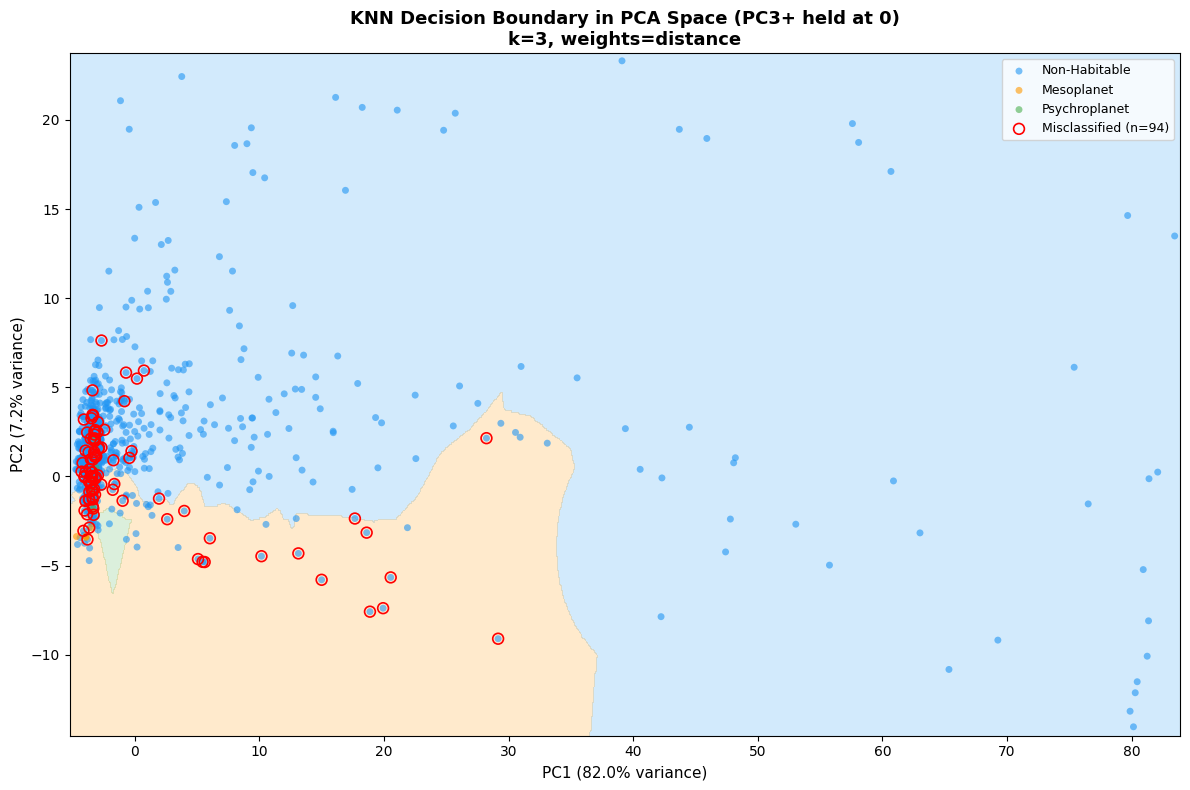

↑ Shaded regions = where KNN assigns each class across PC1/PC2 space.
  PC3+ are held at 0 (their PCA mean) — this is a 2D slice of a higher-dim boundary.
  Red rings = test samples the model got wrong.


In [13]:
n_components = X_train_bal.shape[1]
h = 0.1
x_min, x_max = X_test_scaled[:, 0].min() - 0.5, X_test_scaled[:, 0].max() + 0.5
y_min, y_max = X_test_scaled[:, 1].min() - 0.5, X_test_scaled[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

mesh = np.zeros((xx.ravel().shape[0], n_components))
mesh[:, 0] = xx.ravel()
mesh[:, 1] = yy.ravel()
Z = knn.predict(mesh).reshape(xx.shape)

y_test_arr = y_test.values if hasattr(y_test, "values") else np.asarray(y_test)

fig, ax = plt.subplots(figsize=(12, 8))
ax.contourf(xx, yy, Z, alpha=0.2, levels=[-0.5, 0.5, 1.5, 2.5], colors=colors)

for i, (cls, label, color) in enumerate(zip(classes, class_names, colors)):
    mask = y_test_arr == cls
    ax.scatter(X_test_scaled[mask, 0], X_test_scaled[mask, 1],
               c=color, label=label, alpha=0.6, s=25, edgecolors="none")

misclassified = y_pred_knn != y_test_arr
ax.scatter(X_test_scaled[misclassified, 0], X_test_scaled[misclassified, 1],
           facecolors="none", edgecolors="red", s=60, linewidths=1.2,
           label=f"Misclassified (n={misclassified.sum()})", zorder=4)

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)", fontsize=11)
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)", fontsize=11)
ax.set_title(f"KNN Decision Boundary in PCA Space (PC3+ held at 0)\n"
             f"k={knn.n_neighbors}, weights={knn.weights}",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
save_plot("knn_decision_boundary")
plt.show()

print("↑ Shaded regions = where KNN assigns each class across PC1/PC2 space.")
print("  PC3+ are held at 0 (their PCA mean) — this is a 2D slice of a higher-dim boundary.")
print("  Red rings = test samples the model got wrong.")

### DIAGNOSTIC PLOT 2: k vs CV F1 Macro

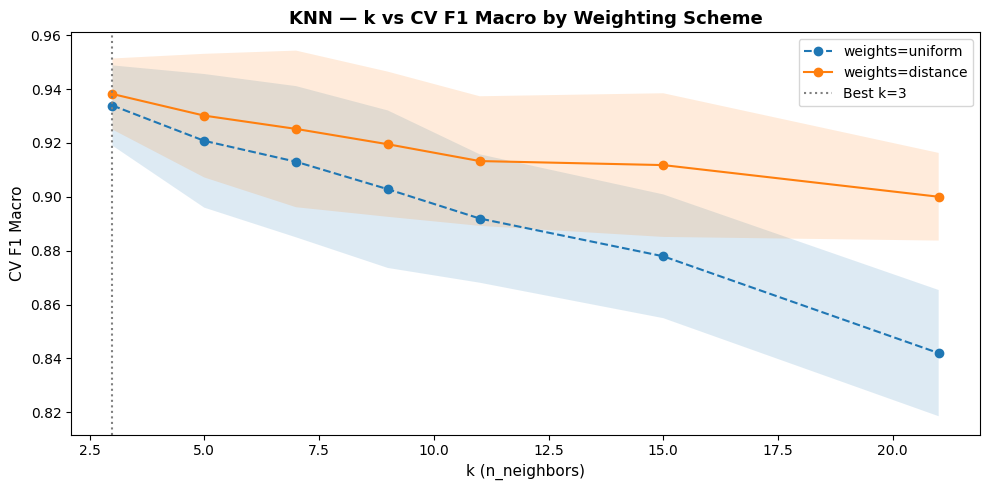

↑ Solid = distance-weighted, dashed = uniform. Shaded band = ±1 std across CV folds.
  Low k = high variance (sensitive to noise), high k = high bias (oversmoothed boundary).


In [14]:
results_df = pd.DataFrame(grid_knn.cv_results_)

fig, ax = plt.subplots(figsize=(10, 5))
for w, ls in [("uniform", "--"), ("distance", "-")]:
    sub = results_df[results_df["param_weights"] == w].sort_values("param_n_neighbors")
    ax.plot(sub["param_n_neighbors"], sub["mean_test_score"],
            marker="o", ls=ls, label=f"weights={w}")
    ax.fill_between(
        sub["param_n_neighbors"],
        sub["mean_test_score"] - sub["std_test_score"],
        sub["mean_test_score"] + sub["std_test_score"],
        alpha=0.15,
    )

ax.axvline(grid_knn.best_params_["n_neighbors"], color="gray", ls=":", lw=1.5,
           label=f"Best k={grid_knn.best_params_['n_neighbors']}")
ax.set_xlabel("k (n_neighbors)", fontsize=11)
ax.set_ylabel("CV F1 Macro", fontsize=11)
ax.set_title("KNN — k vs CV F1 Macro by Weighting Scheme", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
save_plot("knn_k_sensitivity")
plt.show()

print("↑ Solid = distance-weighted, dashed = uniform. Shaded band = ±1 std across CV folds.")
print("  Low k = high variance (sensitive to noise), high k = high bias (oversmoothed boundary).")

### DIAGNOSTIC PLOT 3: Neighbourhood Purity

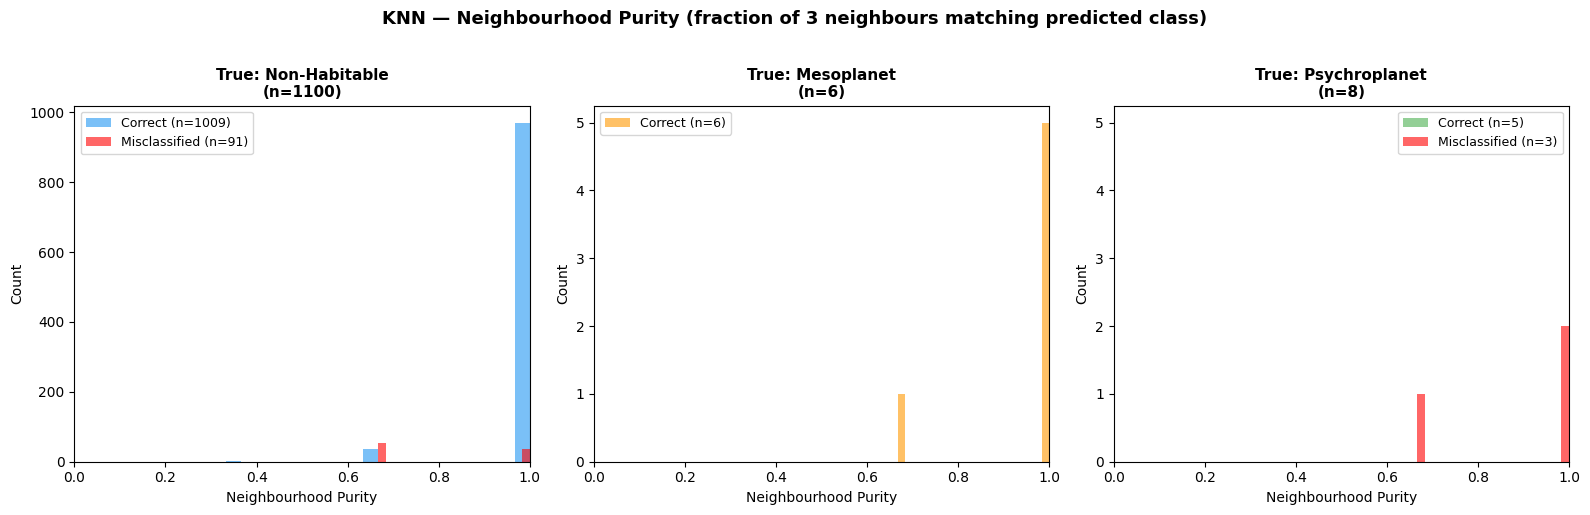

↑ High purity = model is confident — neighbours strongly agree on the predicted class.
  Low purity = mixed neighbourhood — prediction is uncertain.
  Misclassified samples should skew toward lower purity than correct ones.


In [15]:
distances, indices = knn.kneighbors(X_test_scaled)
y_train_arr = y_train_bal.values if hasattr(y_train_bal, "values") else np.asarray(y_train_bal)
y_pred_arr = np.asarray(y_pred_knn)

purity = np.array([
    (y_train_arr[indices[i]] == y_pred_arr[i]).mean()
    for i in range(len(X_test_scaled))
])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for true_cls, ax in zip(range(3), axes):
    mask = y_test_arr == float(true_cls)
    correct_mask = mask & (y_pred_arr == y_test_arr)
    wrong_mask   = mask & (y_pred_arr != y_test_arr)

    if correct_mask.sum() > 0:
        ax.hist(purity[correct_mask], bins=20, alpha=0.6,
                color=colors[true_cls], label=f"Correct (n={correct_mask.sum()})")
    if wrong_mask.sum() > 0:
        ax.hist(purity[wrong_mask], bins=20, alpha=0.6,
                color="red", label=f"Misclassified (n={wrong_mask.sum()})")

    ax.set_xlabel("Neighbourhood Purity", fontsize=10)
    ax.set_ylabel("Count", fontsize=10)
    ax.set_xlim(0, 1)
    ax.set_title(f"True: {class_names[true_cls]}\n(n={mask.sum()})",
                 fontsize=11, fontweight="bold")
    ax.legend(fontsize=9)

fig.suptitle(f"KNN — Neighbourhood Purity (fraction of {knn.n_neighbors} neighbours matching predicted class)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
save_plot("knn_neighbourhood_purity")
plt.show()

print("↑ High purity = model is confident — neighbours strongly agree on the predicted class.")
print("  Low purity = mixed neighbourhood — prediction is uncertain.")
print("  Misclassified samples should skew toward lower purity than correct ones.")

## Metrics
### Classification Report + F1 Scores

KNN — Classification Report
               precision    recall  f1-score   support

Non-Habitable     0.9990    0.9173    0.9564      1100
   Mesoplanet     0.1579    1.0000    0.2727         6
Psychroplanet     0.0758    0.6250    0.1351         8

     accuracy                         0.9156      1114
    macro avg     0.4109    0.8474    0.4548      1114
 weighted avg     0.9878    0.9156    0.9468      1114

F1 Macro:    0.4548
F1 Weighted: 0.9468

5-Fold CV F1 Macro: 0.9455 ± 0.0090
F1 Macro:    0.4548
F1 Weighted: 0.9468


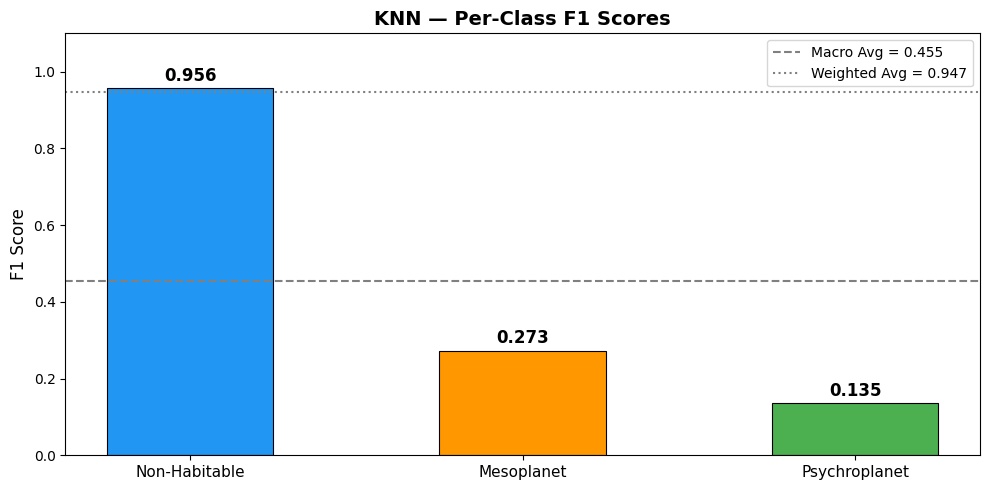

In [16]:
print_classification_report(y_test, y_pred_knn, "KNN")

f1_macro_knn, f1_weighted_knn, _ = compute_f1_scores(y_test, y_pred_knn)

cv_scores_knn = run_stratified_cv(knn, X_train_bal, y_train_bal)

plot_f1_bar(y_test, y_pred_knn, "KNN")

### Confusion Matrix (Counts + Normalized)

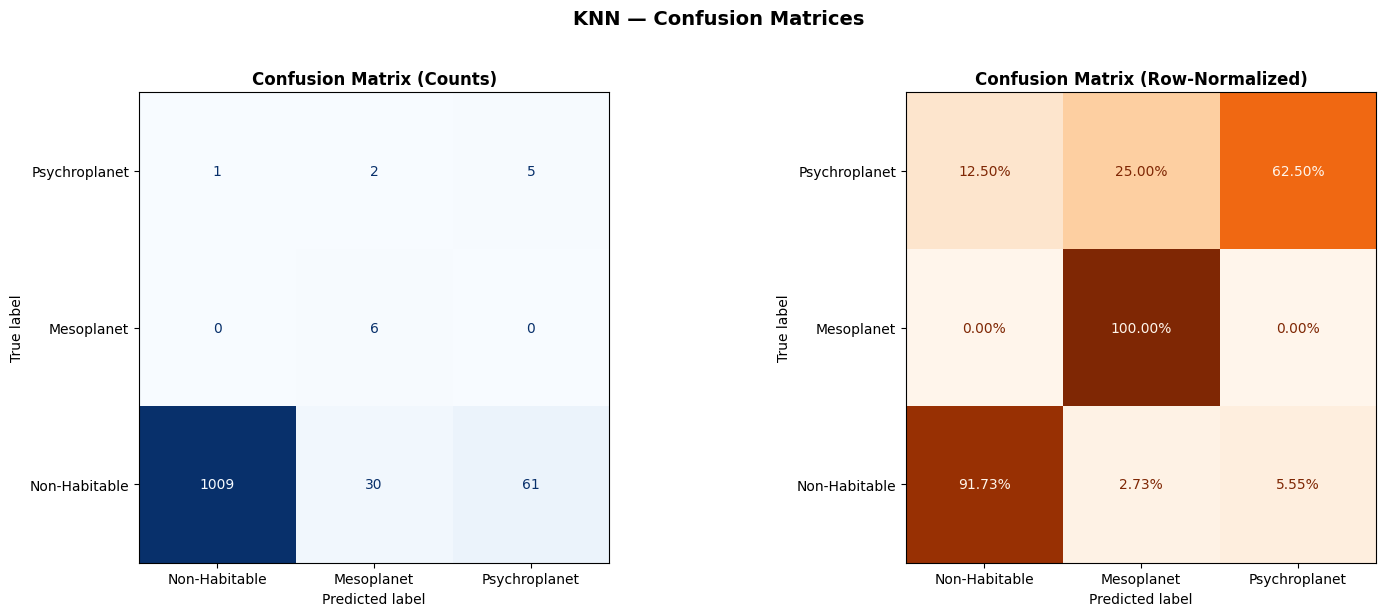

Key error patterns:
  Non-Habitable → predicted Mesoplanet: 30 (2.7% of true Non-Habitable)
  Non-Habitable → predicted Psychroplanet: 61 (5.5% of true Non-Habitable)
  Psychroplanet → predicted Non-Habitable: 1 (12.5% of true Psychroplanet)
  Psychroplanet → predicted Mesoplanet: 2 (25.0% of true Psychroplanet)


In [17]:
plot_confusion_matrices(y_test, y_pred_knn, "KNN")
print_error_patterns(y_test, y_pred_knn)

## Interpretation:
